In [76]:
# 1. Load data
import pandas as pd 
 
df = pd.read_csv("online_retail_II.csv", encoding='ISO-8859-1') 
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [77]:
# 2. Basic inspection
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False))

(1067371, 8)
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
Customer ID    243007
Description      4382
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64



# BASIC CLEANING (required before feature engineering)

In [78]:
# 3. Remove missing customer IDs
df = df.dropna(subset=["Customer ID"])
print(df.isnull().sum().sort_values(ascending=False))

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [79]:
# 4. Remove duplicates
df = df.drop_duplicates()

In [80]:
# 5. Remove invalid transactions
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

In [81]:
# 6. Fix datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [82]:
# 7. Final check
print(df.shape)
df.head()

(779425, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



# FEATURE ENGINEERING

In [83]:
#STEP 1 — Create Revenue (MOST IMPORTANT FEATURE)
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [84]:
#STEP 2 — Extract Time Features
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["Weekday"] = df["InvoiceDate"].dt.day_name()

In [85]:
# ------------------------------
# CUSTOMER-LEVEL FEATURE (aggregation preview)
# ------------------------------

customer_revenue = df.groupby("Customer ID")["TotalPrice"].sum().reset_index()
customer_revenue.columns = ["Customer ID", "TotalSpent"]

In [86]:
# ------------------------------
# PRODUCT-LEVEL FEATURE (aggregation preview)
# ------------------------------

product_revenue = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).reset_index()
product_revenue.columns = ["Product", "TotalRevenue"]

In [87]:
# ------------------------------
# COUNTRY-LEVEL FEATURE (aggregation preview)
# ------------------------------

country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).reset_index()
country_revenue.columns = ["Country", "TotalRevenue"]

In [88]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
 8   TotalPrice   779425 non-null  float64       
 9   Month        779425 non-null  int32         
 10  Day          779425 non-null  int32         
 11  Hour         779425 non-null  int32         
 12  Weekday      779425 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(5)
memory usage: 74.3+ MB


# CORE BUSINESS ANALYSIS

In [89]:
import matplotlib.pyplot as plt

In [90]:
# ------------------------------
# 1. BASIC BUSINESS KPIs
# ------------------------------

# Total Revenue
total_revenue = df["TotalPrice"].sum()

# Total Orders (unique invoices)
total_orders = df["Invoice"].nunique()

# Total Customers
total_customers = df["Customer ID"].nunique()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Revenue: 17374804.268000003
Total Orders: 36969
Total Customers: 5878


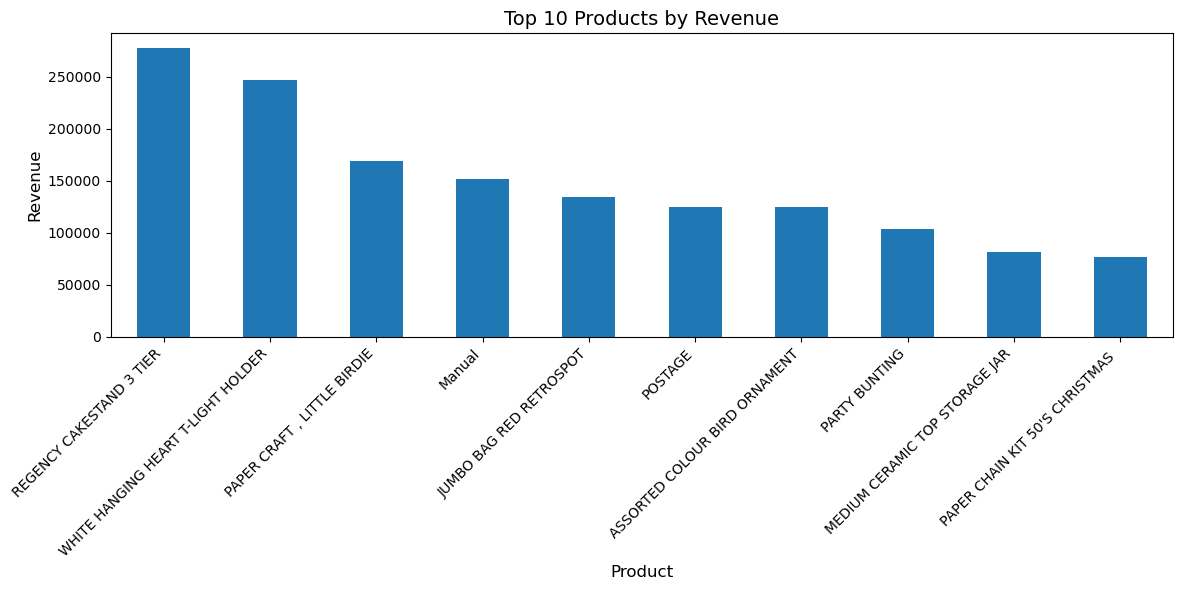

In [91]:
# ------------------------------
# 2. TOP 10 PRODUCTS BY REVENUE
# ------------------------------

# Top 10 products
top_products = df.groupby("Description")["TotalPrice"].sum() \
                 .sort_values(ascending=False).head(10)

# Create figure (make it bigger)
plt.figure(figsize=(12, 6))

# Plot
top_products.plot(kind="bar")

# Title and labels
plt.title("Top 10 Products by Revenue", fontsize=14)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Rotate labels + align properly
plt.xticks(rotation=45, ha="right")

# Improve layout (VERY IMPORTANT)
plt.tight_layout()

plt.show()


Top 10 Customers by Spending:
Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalPrice, dtype: float64


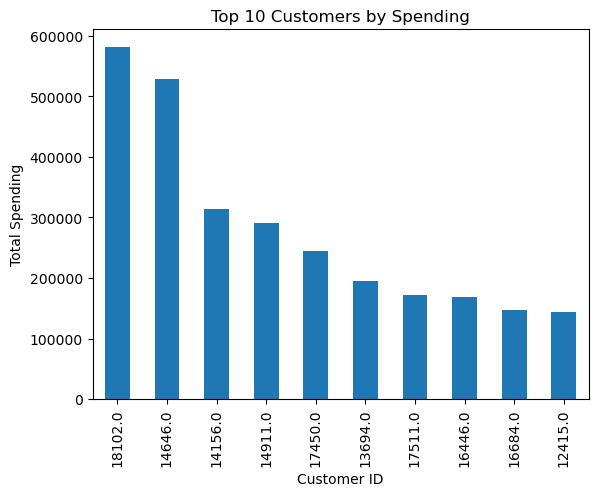

In [92]:
# ------------------------------
# 3. TOP 10 CUSTOMERS BY SPENDING
# ------------------------------

top_customers = df.groupby("Customer ID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Customers by Spending:")
print(top_customers)

# Visualization
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()


Top Countries by Revenue:
Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64


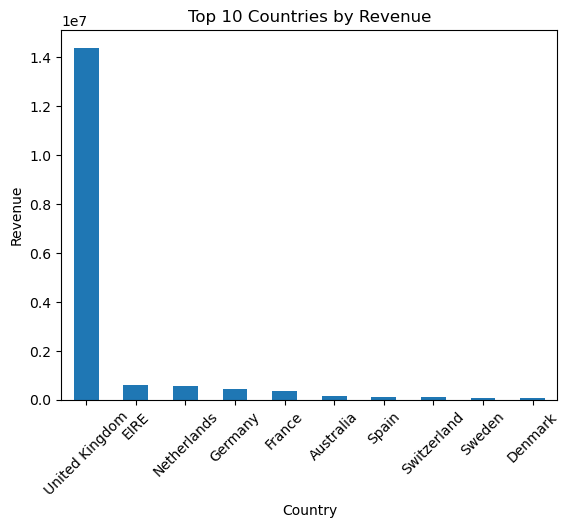

In [93]:
# ------------------------------
# 4. COUNTRY-WISE REVENUE
# ------------------------------

country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

print("\nTop Countries by Revenue:")
print(country_revenue.head(10))

# Visualization
country_revenue.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


Monthly Revenue:
Month
1     1123903.982
2      950643.876
3     1291060.231
4     1060356.333
5     1275188.530
6     1296417.180
7     1188699.071
8     1246275.640
9     1779704.153
10    2068754.460
11    2322665.632
12    1771135.180
Name: TotalPrice, dtype: float64


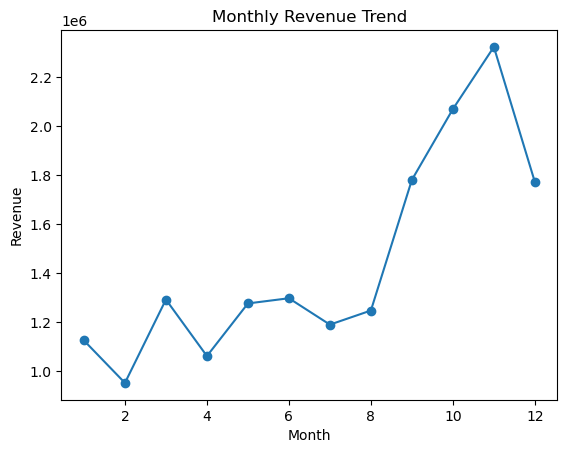

In [94]:
# ------------------------------
# 5. MONTHLY SALES TREND
# ------------------------------

monthly_revenue = df.groupby("Month")["TotalPrice"].sum()

print("\nMonthly Revenue:")
print(monthly_revenue)

# Visualization
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()



Hourly Revenue Pattern:
Hour
6           4.250
7       75745.570
8      524612.550
9     1484450.541
10    2320711.443
11    2235870.393
12    2690583.501
13    2347078.714
14    1962016.161
15    1839607.762
16    1055274.691
17     484477.632
18     190860.290
19     124825.770
20      38685.000
Name: TotalPrice, dtype: float64


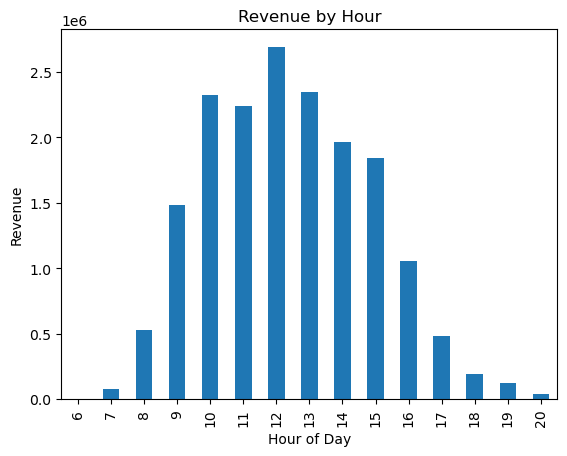

In [95]:
# ------------------------------
# 6. HOURLY SALES PATTERN
# ------------------------------

hourly_revenue = df.groupby("Hour")["TotalPrice"].sum()

print("\nHourly Revenue Pattern:")
print(hourly_revenue)

# Visualization
hourly_revenue.plot(kind="bar")
plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.show()


Weekday Revenue Pattern:
Weekday
Friday       2728473.173
Monday       2778201.566
Saturday        9803.050
Sunday       1768669.052
Thursday     3745783.432
Tuesday      3322830.142
Wednesday    3021043.853
Name: TotalPrice, dtype: float64


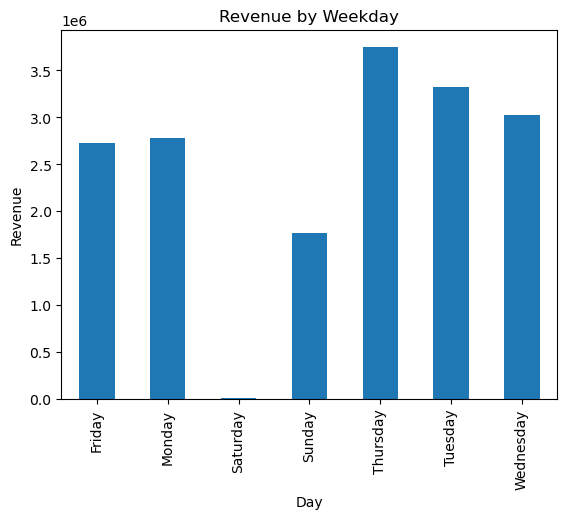

In [96]:
# ------------------------------
# 7. WEEKDAY SALES PATTERN
# ------------------------------

weekday_revenue = df.groupby("Weekday")["TotalPrice"].sum()

print("\nWeekday Revenue Pattern:")
print(weekday_revenue)

# Visualization
weekday_revenue.plot(kind="bar")
plt.title("Revenue by Weekday")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()

# RFM ANALYSIS (CUSTOMER SEGMENTATION)

In [97]:
# Ensure datetime format is correct
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create snapshot date (one day after last transaction in dataset)
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [98]:
# ------------------------------
# 1. CREATE RFM TABLE
# ------------------------------

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Invoice": "count",                                      # Frequency
    "TotalPrice": "sum"                                        # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

In [99]:
# ------------------------------
# 2. RFM SCORING (1–5 SCALE)
# ------------------------------

rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])


In [100]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [101]:
def segment_customer(row):
    if row["R_Score"] == 5 and row["F_Score"] == 5 and row["M_Score"] == 5:
        return "Champions 👑"
    
    elif row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Loyal Customers ❤️"
    
    elif row["R_Score"] >= 4:
        return "New Customers 🟢"
    
    elif row["R_Score"] <= 2:
        return "At Risk ⚠️"
    
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [102]:
# ------------------------------
# 5. SEGMENT DISTRIBUTION
# ------------------------------

segment_counts = rfm["Segment"].value_counts()
print(segment_counts)

Segment
At Risk ⚠️            2347
Others                1167
Loyal Customers ❤️    1064
New Customers 🟢        875
Champions 👑            425
Name: count, dtype: int64


C:\Users\mubas\AppData\Local\Temp\ipykernel_12656\2215944720.py:11: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mubas\AppData\Local\Temp\ipykernel_12656\2215944720.py:11: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mubas\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\mubas\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


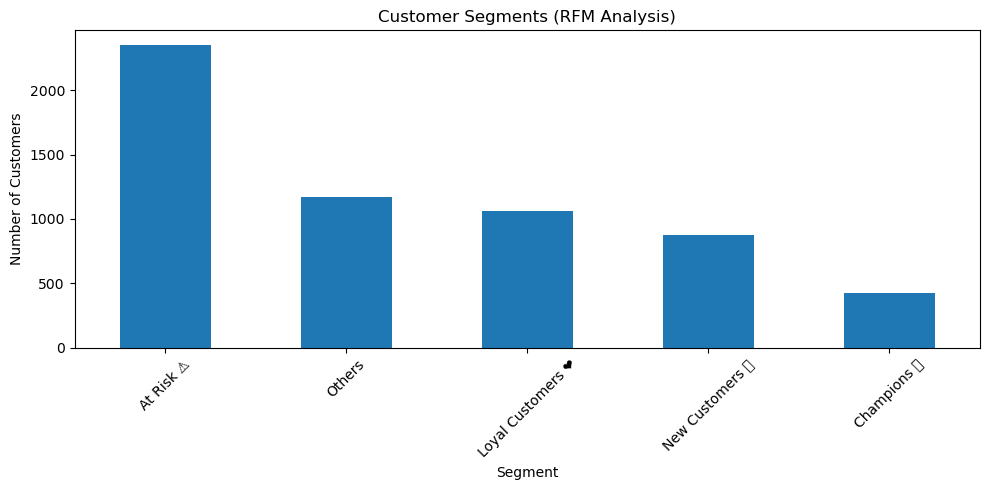

In [103]:
# ------------------------------
# 6. VISUALIZATION
# ------------------------------

plt.figure(figsize=(10,5))
segment_counts.plot(kind="bar")
plt.title("Customer Segments (RFM Analysis)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [104]:
# ------------------------------
# 7. BUSINESS INSIGHTS SUMMARY
# ------------------------------

print("\n--- RFM SUMMARY ---")
print("Total Customers:", rfm.shape[0])
print("Top Segment:", segment_counts.idxmax())


--- RFM SUMMARY ---
Total Customers: 5878
Top Segment: At Risk ⚠️


In [106]:
rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
Customer ID,,,,,,,
12346.0,326,34,77556.46,2,2,5,At Risk ⚠️
12347.0,2,222,4921.53,5,5,5,Champions 👑
12348.0,75,51,2019.40,3,3,4,Others
12349.0,19,175,4428.69,5,5,5,Champions 👑
12350.0,310,17,334.40,2,2,2,At Risk ⚠️
...,...,...,...,...,...,...,...
18283.0,4,938,2664.90,5,5,4,Loyal Customers ❤️
18284.0,432,28,461.68,1,2,2,At Risk ⚠️
18285.0,661,12,427.00,1,1,2,At Risk ⚠️


In [111]:
# Reset index so CustomerID becomes a column
rfm = rfm.reset_index()

# Save clean dataset
rfm.to_csv(
    "rfm_segments_enc.csv",
    index=False,
    encoding="utf-8-sig"
)

ValueError: cannot insert level_0, already exists

In [108]:
rfm

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,12346.0,326,34,77556.46,2,2,5,At Risk ⚠️
1,12347.0,2,222,4921.53,5,5,5,Champions 👑
2,12348.0,75,51,2019.40,3,3,4,Others
3,12349.0,19,175,4428.69,5,5,5,Champions 👑
4,12350.0,310,17,334.40,2,2,2,At Risk ⚠️
...,...,...,...,...,...,...,...,...
5873,18283.0,4,938,2664.90,5,5,4,Loyal Customers ❤️
5874,18284.0,432,28,461.68,1,2,2,At Risk ⚠️
5875,18285.0,661,12,427.00,1,1,2,At Risk ⚠️
5876,18286.0,477,67,1296.43,1,3,4,At Risk ⚠️


In [114]:
rfm.to_csv(
    "rfm_segments.csv",
    index=False,
    encoding="utf-8-sig"
)

In [115]:
import os

path = os.path.join(os.getcwd(), "rfm_segments.csv")

rfm.to_csv(path, index=False, encoding="utf-8-sig")

print("Saved at:", path)

Saved at: C:\Users\mubas\Professional Practice\rfm_segments.csv
